# Typed Muse digits

Following the preprocessing steps from source [12]. Uses mean padding instead of interpolation to ensure same length of data. Then MinMaxScaling, smoothing, and downsampling.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import json
from sklearn.preprocessing import MinMaxScaler
import random
import scipy
from scipy.signal import sosfiltfilt, butter, filtfilt, iirnotch
from scipy.interpolate import interp1d
import os


import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Import the necessary network layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Input

In [ ]:
# Read the data from a txt file, format is tab separated and the last col contains the comma separated eeg data
file_name = 'Insight.txt'
n_channels = 5 # how many EEG channels the dataset uses
sampling_frequency = 220

data_rows = []
# desired_samples = sampling_frequency*2
desired_samples = 300 # the maximum number of datapoints according to the paper

# Load in the data, padding the end of the data sequence with the mean value to ensure same length of data for all points
with open(file_name, 'r') as f:
    lines = f.readlines()

    for line in lines:
        cols = line.strip().split('\t')
        # values = np.array([int(value) for value in cols[-1].split(',')])
        values = np.array([value for value in cols[-1].split(',')])
        # print(values)

        # Perform mean padding, appending the padding values to the end of the data up to 612
        mean = np.average(values)
        pad_size = desired_samples - values.shape[0]
        padding = np.full(pad_size, mean)
        padded_values = np.append(values, padding)

        # Add this row into the big list of rows
        data_rows.append(padded_values)

data = np.array(data_rows)
print(data[:5])

target = np.loadtxt(file_name, delimiter='\t', usecols=4)

# Note that at this point the data is still separated by channel... data isn't clumped into 2d arrays for the same event and target has repeating digits for the same event

['4259.487179' '4237.948717' '4247.179487' '4242.051282' '4233.333333'
 '4251.282051' '4232.820512' '4234.358974' '4224.615384' '4219.487179'
 '4249.743589' '4238.461538' '4245.641025' '4244.615384' '4223.076923'
 '4240.512820' '4234.358974' '4240.512820' '4235.384615' '4224.102564'
 '4255.384615' '4243.589743' '4243.589743' '4248.205128' '4226.666666'
 '4244.102564' '4228.717948' '4225.641025' '4236.923076' '4208.717948'
 '4226.153846' '4234.871794' '4234.871794' '4245.641025' '4233.846153'
 '4263.076923' '4261.025641' '4244.615384' '4261.025641' '4242.051282'
 '4243.589743' '4233.333333' '4221.025641' '4241.538461' '4235.384615'
 '4250.256410' '4235.897435' '4221.538461' '4268.717948' '4257.435897'
 '4238.974358' '4232.307692' '4218.461538' '4244.615384' '4236.410256'
 '4235.384615' '4246.666666' '4238.461538' '4252.820512' '4234.358974'
 '4232.820512' '4247.692307' '4234.871794' '4260.000000' '4249.230769'
 '4233.846153' '4251.282051' '4249.230769' '4272.820512' '4265.128205'
 '4256

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U11'), dtype('<U11')) -> None

In [ ]:
# Reshape so each digit has 4 rows of EEG data for the 4 channels

print("Before reshaping")
print("Data shape is ", data.shape)
print("Target shape is ", target.shape)

data = np.reshape(data, [-1, n_channels, desired_samples])

new_target = []
for i in range(target.shape[0]):
    if (i % n_channels == 0):
        new_target.append(target[i])

new_target = np.array(new_target)
print("After reshaping")
print("Data shape is ", data.shape)
print("Target shape is ", new_target.shape)


target = new_target.astype(int)
print(target[:5])

Before reshaping
Data shape is  (163932, 612)
Target shape is  (163932,)
After reshaping
Data shape is  (40983, 4, 612)
Target shape is  (40983,)
[6 7 6 6 1]


## Preprocess data

Random data point: 30343
Target is  -1


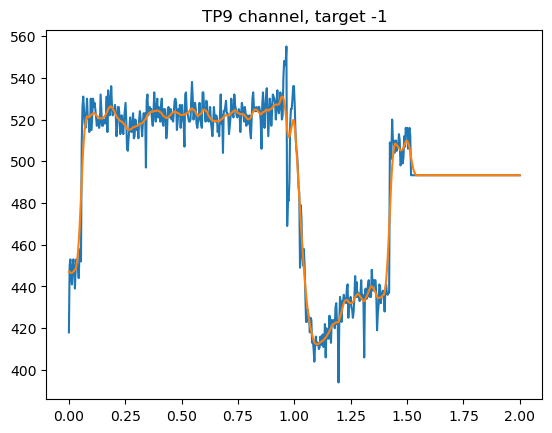

In [ ]:
# Data smoothing to remove noise using TMA filter

# Generated by ChatGPT
def tma_filter(eeg_data, window_size):
    """
    Applies a triangular moving average filter to the EEG data.

    Parameters:
    - eeg_data: np.array, shape (n_channels, n_samples)
      The EEG data to be filtered. Each row corresponds to a channel.
    - window_size: int
      The size of the moving window.

    Returns:
    - filtered_eeg_data: np.array, shape (n_channels, n_samples)
      The filtered EEG data.
    """

    def triangular_kernel(window_size):
        # Generate a triangular kernel
        if window_size % 2 == 0:
            window_size += 1 # make sure the window size is odd
        middle = window_size // 2
        first_half = np.arange(1, middle+2)
        second_half = first_half[:-1][::-1]
        kernel = np.concatenate((first_half, second_half))
        kernel = kernel / kernel.sum()

        return kernel

    kernel = triangular_kernel(window_size)
    smoothed_eeg_data = []

    # Apply filter to each channel
    for i in range(eeg_data.shape[0]):
        mode = 'valid'
        smoothed_channel = np.convolve(eeg_data[i, :], kernel, mode=mode)

        # If mode = 'valid' apply mean padding to front and back of smoothed data
        # if(mode=='valid'):
        #   pad_size = int(eeg_data.shape[1] - smoothed_channel.shape[0])
        #   if (pad_size % 2 == 0):
        #       padding = np.full(int(pad_size / 2), np.average(smoothed_channel))
        #       smoothed_channel = np.append(padding, smoothed_channel) # append to front
        #       smoothed_channel = np.append(smoothed_channel, padding) # append to back

        smoothed_eeg_data.append(smoothed_channel)

    smoothed_eeg_data = np.array(smoothed_eeg_data)

    return smoothed_eeg_data

# smoothed_data = np.zeros_like(data)
# for i in range(data.shape[0]):
#     smoothed_eeg_data = tma_filter(data[i, :], window_size=15) # adjust window size as necessary
#     smoothed_data[i, :] = smoothed_eeg_data

smoothed_data = []
for i in range(data.shape[0]):
    smoothed_eeg_data = tma_filter(data[i, :], window_size=15) # adjust window size as necessary
    smoothed_data.append(smoothed_eeg_data)

smoothed_data = np.array(smoothed_data)


# smoothed_data = np.array(smoothed_data)

# Plot example signal before and after smoothing
random.seed(9)
rand = random.randint(0, data.shape[0])
print("Random data point:", rand)
print("Target is ", target[rand])
raw_sample = data[rand] # all the eeg data from the chosen datapoint
smoothed_sample = smoothed_data[rand]
# time_data = np.linspace(0, 2, desired_samples) # create corresponding time values for each of the eeg signal points, 2 seconds
time_data = np.linspace(0, 2, smoothed_sample.shape[1])

cutoff = int((raw_sample.shape[1] - smoothed_sample.shape[1]) / 2)
plt.figure()
plt.title(f'TP9 channel, target {target[rand]}')
plt.plot(time_data, raw_sample[0, cutoff:raw_sample.shape[1]-cutoff], label='raw data')
plt.plot(time_data, smoothed_sample[0], label='smoothed data')

plt.show()

In [ ]:
print(smoothed_data[rand])
data = smoothed_data

[[447.015625   446.875      446.734375   ... 493.30434783 493.30434783
  493.30434783]
 [512.46875    512.40625    512.09375    ... 515.7826087  515.7826087
  515.7826087 ]
 [499.859375   499.328125   499.046875   ... 508.3826087  508.3826087
  508.3826087 ]
 [439.234375   439.296875   439.328125   ... 486.21521739 486.21521739
  486.21521739]]


Try bandpass filter instead of smoothing (next 3 cells).

Random data point: 30343
Target is  -1


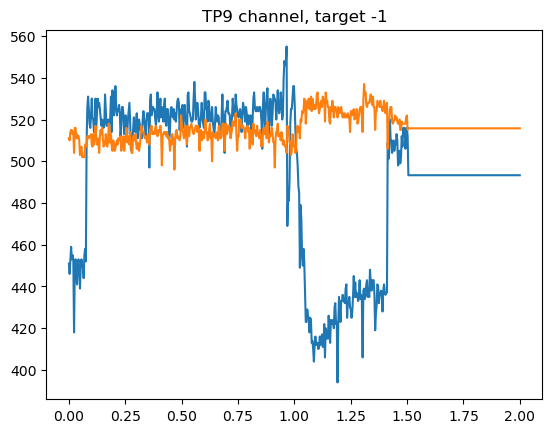

In [ ]:
# Try bandpass filter instead of smoothing

# # Visualize a signal from the first 2 eeg channels (using the a randomly chosen datapoint as an example)
# random.seed(61)
# rand = random.randint(0, data.shape[0])
# print("Random data point:", rand)
# eeg_1 = data[rand] # all the eeg data from the chosen datapoint
# time_data = np.linspace(0, 2, desired_samples) # create corresponding time values for each of the eeg signal points, 2 seconds

# plt.figure()
# plt.plot(time_data, eeg_1[0])
# plt.plot(time_data, eeg_1[1])

# plt.show()

random.seed(9)
rand = random.randint(0, data.shape[0])
print("Random data point:", rand)
print("Target is ", target[rand])
raw_sample = data[rand] # all the eeg data from the chosen datapoint
# time_data = np.linspace(0, 2, desired_samples) # create corresponding time values for each of the eeg signal points, 2 seconds
time_data = np.linspace(0, 2, raw_sample.shape[1])

plt.figure()
plt.title(f'TP9 channel, target {target[rand]}')
plt.plot(time_data, raw_sample[0, :], label='TP9')
plt.plot(time_data, raw_sample[1, :], label='2nd channel')

plt.show()


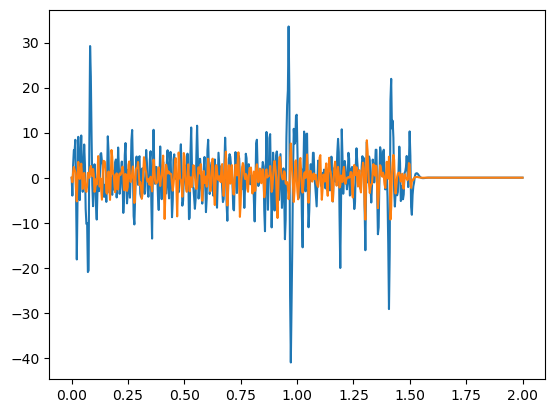

In [ ]:
# Design a Butterworth bandpass filter to apply to the data
sos = butter(2, [14, 71], 'bandpass', fs=sampling_frequency, output='sos') # 2nd order butterworth bandpass filter in frequency ranges 14-71 Hz, specifying the sampling rate

# Apply the filter to the train and test data that have already passed through the notch filter
data_filtered = sosfiltfilt(sos, data)

# Visualize again the signal from the first 2 eeg channels, same random datapoint as before
eeg_1_filtered = data_filtered[rand]

plt.figure()
plt.plot(time_data, eeg_1_filtered[0])
plt.plot(time_data, eeg_1_filtered[1])

plt.show()

In [ ]:
print(data_filtered[rand])
data = data_filtered

[[-2.66236837e-02 -3.98161136e+00  2.78044427e+00 ...  3.85720284e-14
   1.71625208e-15 -3.98919042e-14]
 [ 2.42982287e-03 -1.01254742e+00  1.26619118e+00 ... -1.27406000e-13
  -6.12546663e-14  1.17884731e-14]
 [-2.35013422e-02 -4.00269259e+00 -4.99969679e+00 ... -1.23847635e-14
  -6.85976773e-14 -1.23752104e-13]
 [-9.08555244e-02 -1.63946284e+01 -1.13130015e+01 ... -6.31088724e-30
  -6.31088724e-30 -6.31088724e-30]]


Bandpass filter ends here.

In [ ]:
# Apply min-max scaling to the data EEG sequence
# Using scikit-learn minmaxscaler but not sure if this is the same transform as the paper used... if stuff doesn't work come back here and do this manually

data = np.reshape(data, (data.shape[0], -1))
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data)
print(data[0])

# Reshape back to cnn format
data = np.reshape(data, (data.shape[0], n_channels, -1))
print(data.shape)

[0.47734539 0.48529758 0.49353831 ... 0.50299501 0.50299501 0.50299501]
(40983, 4, 598)


In [ ]:
# Downsample the data to 40 time steps
# Don't know if this paper used Fourier method or polyphase filtering or what
# Try Fourier first and see what happens

n_timesteps = 40 # number of timesteps we're downsampling to
downsampled_data = np.zeros((data.shape[0], n_channels, n_timesteps))
for i in range(data.shape[0]):
    for j in range(n_channels):
        downsampled_data[i, j] = scipy.signal.resample(data[i, j], n_timesteps)


print(downsampled_data.shape)


(40983, 4, 40)


In [ ]:
data = downsampled_data

## Prepare for input into CNN

In [ ]:
# Changing problem to blank vs digit problem (use this cell and next one instead of the 2 after if you want to do this)

# Inspect values and counts of target
target_values, target_counts = np.unique(target, return_counts=True)
print("Values:", target_values)
print("Counts:", target_counts)

# Iterate through target, creating a new target array that's 1 if it's a 0-9 (digit) and -1 if it's -1 (blank)
target_binary = np.zeros_like(target)
for i in range(target_binary.shape[0]):
    if target[i] == -1:
        target_binary[i] = -1
    else:
        target_binary[i] = 0

# Inspect values and counts of target binary array
target_bin_values, target_bin_counts = np.unique(target_binary, return_counts=True)
print("Values:", target_bin_values)
print("Counts:", target_bin_counts)

# Now keep only the first 11103 digit values

# Split both the data and the binary target into those containing digits and those containing -1 blanks
data_digit = data[target_binary >= 0]
data_blank = data[target_binary == -1]
target_digit = target_binary[target_binary >= 0]
target_blank = target_binary[target_binary == -1]

# Add first 11103 of the digits back into the main set
data_binary = np.concatenate((data_blank, data_digit[:11103]), 0) # join these 2 arrays along the 1st (0) axis
target_binary = np.concatenate((target_blank, target_digit[:11103]), 0)

# Inspect values and counts again
target_bin_values, target_bin_counts = np.unique(target_binary, return_counts=True)
print("Values:", target_bin_values)
print("Counts:", target_bin_counts)

Values: [-1  0  1  2  3  4  5  6  7  8  9]
Counts: [11103  2976  2908  2980  2958  2884  3013  3092  3020  3052  2997]
Values: [-1  0]
Counts: [11103 29880]
Values: [-1  0]
Counts: [11103 11103]


In [ ]:
N_CLASSES = 2 # blank/digit classification
INPUT_SHAPE = (n_channels, n_timesteps, 1) # 1 color channel
BATCH_SIZE = 32

# Split into train and test set and relabel as X and y
X_train, X_test, y_train, y_test = train_test_split(data_binary, target_binary, test_size=0.2, random_state=62, shuffle=True)

# Inspect values and counts of y_train
y_train_values, y_train_counts = np.unique(y_train, return_counts=True)
print("Values:", y_train_values)
print("Counts:", y_train_counts)
print(y_train.shape)

# One hot encoding
y_train = to_categorical(y_train, N_CLASSES)
y_test = to_categorical(y_test, N_CLASSES)
print(y_train[:10])

# Split train into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)

print(X_train.shape)
print(X_val.shape)

Values: [-1  0]
Counts: [8876 8888]
(17764,)
[[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
(14211, 4, 40)
(3553, 4, 40)


Values: [-1  1]
Counts: [8876 8888]
(17764,)


In [ ]:
# Adjusting number of blank values

# Inspect values and counts of target
target_values, target_counts = np.unique(target, return_counts=True)
print("Values:", target_values)
print("Counts:", target_counts)

# Split both the data and the target into those containing 0-9 targets and those containing -1 targets
data_digit = data[target >= 0]
data_blank = data[target == -1]
target_digit = target[target >= 0]
target_blank = target[target == -1]

# # Add first 3000 of the blanks back into the main set
# data = np.concatenate((data_digit, data_blank[:3000]), 0) # join these 2 arrays along the 1st (0) axis
# target = np.concatenate((target_digit, target_blank[:3000]), 0)

# Remove the blanks
data = data_digit
target = target_digit

# Now inspect the values and counts again
print("\nAdjusted number of blanks")
target_values, target_counts = np.unique(target, return_counts=True)
print("Values:", target_values)
print("Counts:", target_counts)

print("Data shape: ", data.shape)


Values: [-1  0  1  2  3  4  5  6  7  8  9]
Counts: [11103  2976  2908  2980  2958  2884  3013  3092  3020  3052  2997]

Adjusted number of blanks
Values: [0 1 2 3 4 5 6 7 8 9]
Counts: [2976 2908 2980 2958 2884 3013 3092 3020 3052 2997]
Data shape:  (29880, 4, 40)


In [ ]:
N_CLASSES = 10 # change this depending on whether you removed the -1 targets (blank, non-digit events) or not
INPUT_SHAPE = (n_channels, n_timesteps, 1) # 1 color channel
BATCH_SIZE = 32

# Split into train and test set and relabel as X and y
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=62, shuffle=True)

# One hot encoding
y_train = to_categorical(y_train, N_CLASSES)
y_test = to_categorical(y_test, N_CLASSES)
print(y_train[0])

# Split train into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)

print(X_train.shape)
print(X_val.shape)

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
(19123, 4, 40)
(4781, 4, 40)


## Build and train CNN

In [ ]:
# Build the model from the paper [12]
# This model is modified slightly in that the first kernel is a col vector instead of a row vector, to try to separate space and time domains [2]

model = Sequential()
model.add(Input(shape=INPUT_SHAPE))
model.add(Conv2D(filters=36, kernel_size=(n_channels, 5), activation='relu'))
model.add(Conv2D(filters=12, kernel_size=(1, 5), activation='relu'))
model.add(Conv2D(filters=12, kernel_size=(1, 5), activation='relu'))
# model.add(Conv2D(filters=))
model.add(Flatten())
model.add(Dense(80, activation='relu'))
model.add(Dense(N_CLASSES, activation='softmax'))

optimizer = 'adam'
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()


Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_37 (Conv2D)          (None, 1, 40, 36)         180       
                                                                 
 conv2d_38 (Conv2D)          (None, 1, 36, 12)         2172      
                                                                 
 conv2d_39 (Conv2D)          (None, 1, 32, 12)         732       
                                                                 
 flatten_10 (Flatten)        (None, 384)               0         
                                                                 
 dense_24 (Dense)            (None, 80)                30800     
                                                                 
 dense_25 (Dense)            (None, 10)                810       
                                                                 
Total params: 34,694
Trainable params: 34,694
Non-tra

In [ ]:
hist = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=100, validation_data=(X_val, y_val))

Epoch 1/100


598/598 [==============================] - 2s 2ms/step - loss: 2.3029 - accuracy: 0.1035 - val_loss: 2.3031 - val_accuracy: 0.1017
Epoch 2/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.1018 - val_loss: 2.3033 - val_accuracy: 0.1017
Epoch 3/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.1023 - val_loss: 2.3032 - val_accuracy: 0.0929
Epoch 4/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.0992 - val_loss: 2.3032 - val_accuracy: 0.1017
Epoch 5/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3032 - val_accuracy: 0.0929
Epoch 6/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.1006 - val_loss: 2.3035 - val_accuracy: 0.0929
Epoch 7/100
598/598 [==============================] - 1s 2ms/step - loss: 2.3026 - accuracy: 0.1035 - val_loss: 2.3034 - val_accuracy: 0.1017
Epoch 8/100

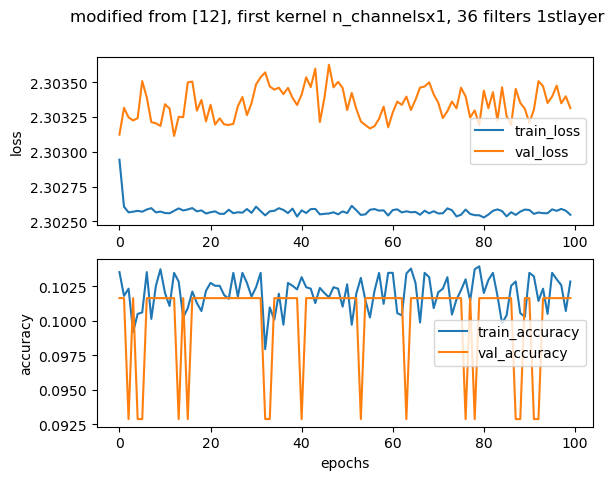

In [ ]:
file_save_path = "train_result/cnn/Muse/"

if not os.path.exists(file_save_path):
    os.mkdir(file_save_path)

# Plot the training history
fig, ax = plt.subplots(2)
fig.suptitle("modified from [12], first kernel n_channelsx1, 36 filters 1stlayer")
ax[0].set(ylabel='loss')
ax[1].set(xlabel='epochs', ylabel='accuracy')

ax[0].plot(hist.history['loss'], label='train_loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='train_accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].legend()

plt.savefig(file_save_path+"col_kernel_modified_no_blanks")

plt.show()